In [1482]:
# import os
# import sys
# from pathlib import Path
# import shutil
# import datetime
# import math

# import attrs
# from liblaf import cherries
# from loguru import logger
# from tqdm import tqdm

# # 替换此行
# # sys.path.insert(0, os.path.abspath(os.path.join(os.path.dirname(__file__), "../../src")))

# # 方法1：使用当前工作目录
# notebook_dir = os.getcwd()  # 获取当前工作目录
# src_path = os.path.abspath(os.path.join(notebook_dir, "../../src"))
# sys.path.insert(0, src_path)


# import qoc
# import qoc.api as api # pyright: ignore


# db: str = qoc.data_dir("database").as_uri().replace("file://", "lmdb://")


# online: bool = False

# symbols: list[str] = [
#     "BTCUSDT", "ETHUSDT", "BNBUSDT", "SOLUSDT", "XRPUSDT", "ADAUSDT", "DOGEUSDT", "AVAXUSDT",
#     "LINKUSDT", "TRXUSDT", "DOTUSDT", "MATICUSDT", "LTCUSDT", "UNIUSDT", "ATOMUSDT", "ETCUSDT",
#     "ICPUSDT", "APTUSDT", "FILUSDT", "NEARUSDT", "HBARUSDT", "INJUSDT", "OPUSDT", "ARBUSDT",
#     "SUIUSDT", "SEIUSDT", "RENDERUSDT", "TIAUSDT", "FTMUSDT", "EGLDUSDT", "AAVEUSDT", "GALAUSDT",
#     "IMXUSDT", "PEPEUSDT", "SHIBUSDT", "FLOKIUSDT", "BONKUSDT", "WIFUSDT", "PENGUUSDT", "TRUMPUSDT",
#     "POLUSDT", "ENSUSDT", "JUPUSDT", "PYTHUSDT", "ORDIUSDT", "SATOSHIUSDT", "SATSUSDT", "MOVRUSDT",
#     "DYMUSDT", "NOTUSDT", "MAGAUSDT", "SPXUSDT"
# ]



# # symbols: list[str] = ["BTCUSDT", "DOGEUSDT"]
# transaction_fee: float = 0.01  # 交易费用为0.1%
# interval: str = "5m"
# start_date: str = "2024-09-01"
# end_date: str = "2025-08-31"
# output_dir: str = "mmpair-strategy/5m_klines_raw"


# offline_db_path = Path("mmpair-strategy")
# if offline_db_path.exists():
#     # logger.info(f"删除现有数据库文件夹: {offline_db_path}")
#     shutil.rmtree(offline_db_path)


# from offline_fetch import fetch_for_offline
# import arcticdb as adb
# uri = "lmdb://mmpair-strategy"

# ac = adb.Arctic(uri)

# qoc_library = ac.get_library('market', create_if_missing=True)

# fetch_for_offline(symbols, interval, start_date, end_date, output_dir, qoc_library)


In [1483]:
# major_list = [
#     "BTCUSDT",
#     "ETHUSDT",
#     "LTCUSDT",
#     "XRPUSDT",
#     "ADAUSDT",
#     "SOLUSDT",
#     "BNBUSDT",
#     "LINKUSDT",
# ]
# meme_list = [
#     "DOGEUSDT",
#     "SHIBUSDT",
#     "PEPEUSDT",
#     "PENGUUSDT",
#     "BONKUSDT",
#     "TRUMPUSDT",
#     "SPXUSDT",
#     "FLOKIUSDT",
#     "WIFUSDT",
# ]

In [1484]:
# # by million

# volume_dict = {
#     "BTCUSDT": 19.92,
#     "ETHUSDT": 120.7,
#     "XRPUSDT": 59.77 * 1000,
#     "BNBUSDT": 139.18,
#     "SOLUSDT": 543.03,
#     "ADAUSDT": 35.79 * 1000,
#     "LINKUSDT": 678.09,
#     "LTCUSDT": 76.31,
#     "DOGEUSDT": 151 * 1000,
#     "SHIBUSDT": 589.24 * 1000000,
#     "PEPEUSDT": 420.68 * 1000000,
#     "PENGUUSDT": 62.86 * 1000,
#     "BONKUSDT": 81.21 * 1000000,
#     # "TRUMPUSDT": 199.99,
#     "SPXUSDT": 930.99,
#     "FLOKIUSDT": 9.53 * 1000000,
#     "WIFUSDT": 998.83,
# }

In [2]:
from pathlib import Path

import pandas as pd

output_dir = "mmpair-strategy/5m_klines_raw"
output_path = Path(output_dir)

coins_dict = {}
    
for file in output_path.iterdir():
    if file.is_file() and file.suffix.lower() == ".csv":
        df = pd.read_csv(file, encoding="utf-8")

        df["Close Time"] = df["Close Time"].apply(
            lambda x: x * 1000 + 999 if x < 2000000000000 else x
        )

        df["Close Time"] = pd.to_datetime(df["Close Time"], unit="us")

        df.columns = df.columns.str.strip().str.replace("\ufeff", "", regex=False)

        if "Close" not in df.columns or "Close Time" not in df.columns:
            print(f"⚠️ 跳过无 Close 或 Close Time 的文件: {file.name}")
            continue

        df.set_index("Close Time", inplace=True)
        symbol = file.stem.split("_")[0]
        
        if len(df) ==105120:
            coins_dict[symbol] = df
            print(f"Processing symbol: {symbol}, length: {len(df)}")

        # if symbol == "ADAUSDT":
        #     ada = df
        # elif symbol == "BNBUSDT":
        #     bnb = df
        # elif symbol == "BONKUSDT":  
        #     bonk = df
        # elif symbol == "BTCUSDT":
        #     btc = df
        # elif symbol == "DOGEUSDT":
        #     doge = df
        # elif symbol == "ETHUSDT":
        #     eth = df
        # elif symbol == "FLOKIUSDT":
        #     floki = df
        # elif symbol == "LINKUSDT":
        #     link = df
        # elif symbol == "LTCUSDT":
        #     ltc = df
        # elif symbol == "PEPEUSDT":
        #     pepe = df
        # elif symbol == "PENGUUSDT":
        #     pengu = df
        # elif symbol == "SHIBUSDT":
        #     shib = df
        # elif symbol == "SOLUSDT":
        #     sol = df
        # elif symbol == "TRUMPUSDT":
        #     trump = df
        # elif symbol == "WIFUSDT":
        #     wif = df
        # elif symbol == "XRPUSDT":
        #     xrp = df
        # else:
        #     print(f"⚠️ 未知符号，跳过文件: {file.name}")
        #     continue

btc = coins_dict["BTCUSDT"]

HEDGE_LIST = {k: v for k, v in coins_dict.items() if k != "BTCUSDT"}


FileNotFoundError: [Errno 2] No such file or directory: 'mmpair-strategy/5m_klines_raw'

# 高波动筛选

In [1486]:
# HEDGE_LIST = {
#     # "LTC": ltc,
#     # "XRP": xrp,
#     # "ADA": ada,
#     # "SOL": sol,
#     # "BNB": bnb,
#     # "LINK": link,
#     "DOGE": doge,
#     "SHIB": shib,
#     "PEPE": pepe,
#     "WIF": wif,
#     "FLOKI" : floki,
#     "BONK": bonk,

# }

# 截取前半段（会真正修改 HEDGE_LIST 中的每个 DataFrame）
half_length = 105120// 3

i=2

for name, df in HEDGE_LIST.items():
#     HEDGE_LIST[name] = df.iloc[(i-1)*half_length:i*half_length]    
    
# btc = btc.iloc[(i-1)*half_length:i*half_length]    



    HEDGE_LIST[name] = df
    
btc = btc

In [1487]:


# # === 参数 ===
FORWARD_WINDOW = 48
BACK_WINDOW = 288

# === 参数 ===
# forward_window = 12
# BACK_WINDOW = 96


TRANSACTION_FEE = 0.001

MIN_POR = 0.0

BULLET_SIZE = 1000
INITIAL = 10000

In [1488]:


# # === 参数 ===



# FORWARD_WINDOW = 48
# BACK_WINDOW = 288
# A = 15
# B = 15


import numpy as np

from scipy.optimize import linprog

import matplotlib.pyplot as plt
from collections import deque
from sklearn.linear_model import LinearRegression
from tqdm import tqdm
import random


In [1489]:

# resi = []
# back_window = BACK_WINDOW
# forward_window = FORWARD_WINDOW
# a = A
# b = B

def backtest_strategy(back_window, forward_window, a, b):
    # === 初始化滑动窗口 ===
    btc_window = deque(btc['Close'][:back_window], maxlen=back_window)
    coin_windows = {name: deque(df['Close'][:back_window], maxlen=back_window) for name, df in HEDGE_LIST.items()}

    num = 0


    stats = []
    revenues = []

    capital = INITIAL
    transaction_fee = TRANSACTION_FEE
    bullet_size = BULLET_SIZE

    time_range = range(back_window, len(btc) - forward_window)

    # === 滑动回归循环 + tqdm 进度条 ===
    # for t in tqdm(range(BACK_WINDOW, len(btc) - FORWARD_WINDOW), desc="Sliding regression progress"):
    for i, t in tqdm(enumerate(time_range), total=len(time_range), desc="Sliding window"):
    # for i, t in (enumerate(time_range)):


        btc_window.append(btc['Close'].iloc[t])


        corr_array = []

        coef_records = {name: [] for name in HEDGE_LIST.keys()}

        for name, df in HEDGE_LIST.items():
            # 更新当前币种窗口
            coin_windows[name].append(df['Close'].iloc[t])

            if i%forward_window == 0:
                # 提取 y、X
                y = np.array(coin_windows[name]).reshape(-1, 1)
                X_btc = np.array(btc_window).reshape(-1, 1)

                # === 第一次线性回归：coin ~ btc ===
                model_btc = LinearRegression(fit_intercept=True)
                model_btc.fit(X_btc, y)


                coef_btc = model_btc.coef_[0][0]
                # intercept_btc = model_btc.intercept_[0]


                y_pred_btc = model_btc.predict(X_btc)
                residual_btc = (y - y_pred_btc)

                            # 计算收益率： r_t = p_t / p_{t-1} - 1
                y_ret = y[1:] / y[:-1] - 1
                x_ret = X_btc[1:] / X_btc[:-1] - 1


                corr_array.append(np.corrcoef(y_ret.flatten(), x_ret.flatten())[0, 1])


                

                coef_records[name] = {
                    'coef': coef_btc,
                    'correlation': np.corrcoef(y_ret.flatten(), x_ret.flatten())[0, 1],
                    'residual': residual_btc[-1, 0]/coef_btc,
                }

                


                # # === 随机展示结果（1% 概率）===
                # if random.random() < 0.0001:
                #     print(f"\nCoin: {name} | t = {t}")
                #     print(f"BTC Regression → β: {model_btc.coef_[0,0]:.4f}, α: {model_btc.intercept_[0]:.4f}")
                #     # === 可视化单图 ===
                #     plt.figure(figsize=(6, 4))
                #     plt.title(f"Regression of {name} on BTC (Window ending t={t})", fontsize=13, fontweight='bold')

                #     plt.plot(residual_btc, label='BTC Residual / Coin Price', color='steelblue', linewidth=1.3)
                #     plt.axhline(0, color='gray', linestyle='--', linewidth=0.8)

                #     plt.xlabel("Window index")
                #     plt.ylabel("Residual / Coin Price")
                #     plt.grid(alpha=0.3)
                #     plt.legend()
                #     plt.tight_layout()
                #     plt.show()



        if i % forward_window == 0:
            # print(f"\n=== Step {i}: Coefficients collected for all coins ===")
            # === 将 coef_records 转为 DataFrame ===
            coef_df = pd.DataFrame.from_dict(coef_records, orient='index')  # index=coin

            # === 确保 residual 列是 float ===
            coef_df['residual'] = coef_df['residual'].astype(float)
            coef_df['correlation'] = coef_df['correlation'].astype(float)

            # === 找出 residual 最大/最小的币种 ===
            sorted_df = coef_df.sort_values(by='residual', key=lambda x: x)  # 升序

            min_residual = sorted_df['residual'].iloc[0]           # 最小绝对值
            min2_residual = sorted_df['residual'].iloc[1]          # 第二小绝对值
            min3_residual = sorted_df['residual'].iloc[2]          # 第二小绝对值
            max3_residual = sorted_df['residual'].iloc[-3]         # 第二大绝对值
            max2_residual = sorted_df['residual'].iloc[-2]         # 第二大绝对值
            max_residual = sorted_df['residual'].iloc[-1]         # 最大绝对值

            # min_name = sorted_df.index[0]
            # min2_name = sorted_df.index[1]
            # max2_name = sorted_df.index[-2]
            # max_name = sorted_df.index[-1]



            # === 如果差值超过阈值 ===
            if np.all(coef_df['coef'] > 0): #and max2_residual * min2_residual<0: #and coef_df['correlation'].mean() < 0.7:
                size = max_residual - min_residual


                min_coef = sorted_df['coef'].iloc[0]
                min2_coef = sorted_df['coef'].iloc[1]
                min3_coef = sorted_df['coef'].iloc[2]
                max3_coef = sorted_df['coef'].iloc[-3]
                max2_coef = sorted_df['coef'].iloc[-2]
                max_coef = sorted_df['coef'].iloc[-1]

                min_name = sorted_df.index[0]
                min2_name = sorted_df.index[1]
                min3_name = sorted_df.index[2]
                max3_name = sorted_df.index[-3]
                max2_name = sorted_df.index[-2]
                max_name = sorted_df.index[-1]

                min_price = HEDGE_LIST[min_name]['Close'].iloc[t]
                min2_price = HEDGE_LIST[min2_name]['Close'].iloc[t]
                min3_price = HEDGE_LIST[min3_name]['Close'].iloc[t]
                max3_price = HEDGE_LIST[max3_name]['Close'].iloc[t]
                max2_price = HEDGE_LIST[max2_name]['Close'].iloc[t]
                max_price = HEDGE_LIST[max_name]['Close'].iloc[t]

                min_correlation = sorted_df['correlation'].iloc[0]
                min2_correlation = sorted_df['correlation'].iloc[1]
                min3_correlation = sorted_df['correlation'].iloc[2]
                max3_correlation = sorted_df['correlation'].iloc[-3]
                max2_correlation = sorted_df['correlation'].iloc[-2]
                max_correlation = sorted_df['correlation'].iloc[-1]


                theta_names = ['theta_min', 'theta_min2', 'theta_min3', 'theta_max3', 'theta_max2', 'theta_max']

                residuals = np.array([min_residual, min2_residual, min3_residual, max3_residual, max2_residual, max_residual], dtype=float)
                coefs = np.array([min_coef, min2_coef, min3_coef, max3_coef, max2_coef, max_coef], dtype=float)

                # 目标函数：最小化 sum(theta_i * residual_i)
                c = residuals.copy() * coefs.copy()

                # 等式约束
                A_eq = np.array([
                    coefs,
                    [min_price, min2_price, min3_price, -max3_price, -max2_price, -max_price]
                ], dtype=float)

                position = bullet_size 
                # position = 1000000/max(bullet_size, size/2)
                b_eq = np.array([0.0, position], dtype=float)

                # 不等式约束 |theta_i * price_i| >= 100
                price_vec = np.array([min_price, min2_price, min3_price, max3_price, max2_price, max_price], dtype=float)
                min_abs = position*MIN_POR

                # 初始化 A_ub, b_ub 列表
                A_ub = []
                b_ub = []

                # theta_min, theta_min2 > 0 → θ * price >= 100 → -θ*price <= -100
                A_ub.append([-price_vec[0], 0, 0, 0, 0, 0])
                b_ub.append(-min_abs)
                A_ub.append([0, -price_vec[1], 0, 0, 0, 0])
                b_ub.append(-min_abs)
                A_ub.append([0, 0, -price_vec[2], 0, 0, 0])
                b_ub.append(-min_abs)

                # theta_max2, theta_max < 0 → θ * price <= -100 → θ*price <= -100
                A_ub.append([0, 0, 0, price_vec[3], 0, 0])
                b_ub.append(-min_abs)            
                A_ub.append([0, 0, 0, 0, price_vec[4], 0])
                b_ub.append(-min_abs)
                A_ub.append([0, 0, 0, 0, 0, price_vec[5]])
                b_ub.append(-min_abs)

                A_ub = np.array(A_ub, dtype=float)
                b_ub = np.array(b_ub, dtype=float)

                # 符号约束
                bounds = [
                    (1e-12, None),   # theta_min > 0
                    (1e-12, None),   # theta_min2 > 0
                    (1e-12, None),   # theta_min3 > 0
                    (None, -1e-12),  # theta_max3 < 0
                    (None, -1e-12),  # theta_max2 < 0
                    (None, -1e-12)   # theta_max < 0
                ]

                # 求解
                res = linprog(c=c, A_eq=A_eq, b_eq=b_eq, A_ub=A_ub, b_ub=b_ub, bounds=bounds, method='highs')


                if res.success:
                    theta = res.x
                    objective_value = res.fun
                    # if objective_value < -10 and objective_value > -40:

                    # 构建展示 DataFrame
                    df = pd.DataFrame({
                        'name': [min_name, min2_name, min3_name, max3_name, max2_name, max_name],
                        'coef': coefs,
                        'price': [min_price, min2_price, min3_price, max3_price, max2_price, max_price],
                        'correlation': [min_correlation, min2_correlation, min3_correlation, max3_correlation, max2_correlation, max_correlation],
                        'residual': residuals,
                        'theta': theta,
                        'theta*residual': theta * residuals,
                        'theta*price': theta * np.array([min_price, min2_price, min3_price, max3_price, max2_price, max_price], dtype=float),
                        'theta*coef': theta * coefs
                    })
                        
                    avg_correlation = abs((theta * residuals * coefs) ) @ abs(df['correlation'])
                    avg_residual = theta @ (residuals*coefs) 

                    if objective_value < -a and avg_correlation<b:

                        num+=1    

                        corr_array = np.array(corr_array)
                        stats.append(corr_array.mean())

                        revenue = 0

                        for idx, row in df.iterrows():
                            name = row['name']
                            theta_value = row['theta']
                            price = HEDGE_LIST[name]['Close'].iloc[t]
                            future_price = HEDGE_LIST[name]['Close'].iloc[t + forward_window]
                            num_coins = theta_value
                            revenue += (future_price - price) * num_coins
                        revenues.append(revenue)
                    

    res_array = np.array(revenues)
    sharpe = res_array.mean() / res_array.std()
    print("Sharpe Ratio:", sharpe, "A:", a, "B:", b, "FW:", forward_window, "BW:", back_window, "Num Trades:", len(revenues), "Avg Revenue:", res_array.mean())
    return stats, revenues

# A_LIST = [0, 15, 25]
# B_LIST = [15, 30, 45, 999]
# FORWARD_WINDOW_LIST = [12, 24, 48, 96]
# BACK_WINDOW_LIST = [96, 192, 288, 576]
# for a in A_LIST:
#     for b in B_LIST:
#         for forward_window in FORWARD_WINDOW_LIST:
#             for back_window in BACK_WINDOW_LIST:
#                 backtest_strategy(back_window, forward_window, a, b)


back_window = 288
forward_window = 48
a = 25
b = 999

stats, revenues = backtest_strategy(back_window, forward_window, a, b)


Sliding window: 100%|██████████| 104784/104784 [00:43<00:00, 2392.27it/s]

Sharpe Ratio: 0.03125162588092125 A: 25 B: 999 FW: 48 BW: 288 Num Trades: 478 Avg Revenue: 0.792439927561569


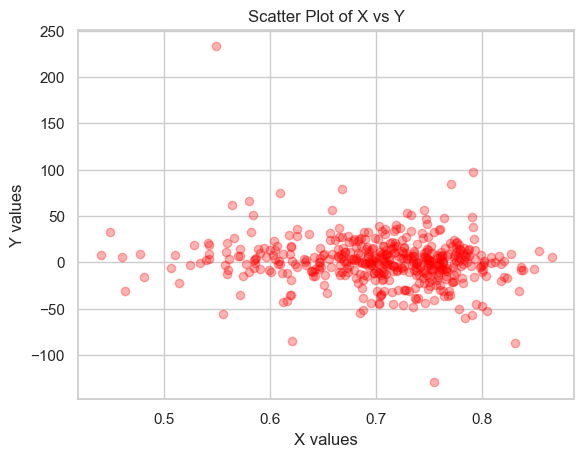

In [1490]:
import matplotlib.pyplot as plt

x = stats
y = revenues

plt.scatter(x, y, color='red', alpha=0.3)
plt.xlabel("X values")
plt.ylabel("Y values")
plt.title("Scatter Plot of X vs Y")
plt.grid(True)
plt.show()


/var/folders/j9/n79dq8zs23qbyhwf5323s_lw0000gn/T/ipykernel_19850/1193009734.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_means = pd.DataFrame({'x_bin': bin_labels, 'y': y}).groupby('x_bin')['y'].mean()


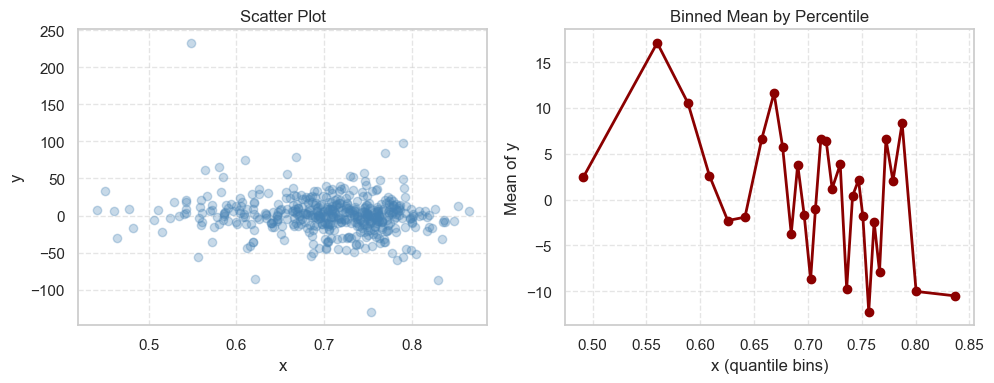

In [1491]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

x = np.array(stats)
y = np.array(revenues)

# === 按百分比分箱 ===
n_bins = 30
quantiles = np.linspace(0, 1, n_bins + 1)
bins = np.quantile(x, quantiles)  # 按x的分位数分箱

# 为避免重复的边界（在x有重复值时）
bins = np.unique(bins)

bin_labels = pd.cut(x, bins=bins, include_lowest=True)
bin_means = pd.DataFrame({'x_bin': bin_labels, 'y': y}).groupby('x_bin')['y'].mean()
bin_centers = [(interval.left + interval.right) / 2 for interval in bin_means.index]

# === 两个子图（不共享 y） ===
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4), sharey=False)

# 左边：散点图
ax1.scatter(x, y, alpha=0.3, color='steelblue')
ax1.set_xlabel("x")
ax1.set_ylabel("y")
ax1.set_title("Scatter Plot")
ax1.grid(True, linestyle='--', alpha=0.5)

# 右边：分箱均值图
ax2.plot(bin_centers, bin_means.values, color='darkred', marker='o', lw=2)
ax2.set_xlabel("x (quantile bins)")
ax2.set_ylabel("Mean of y")
ax2.set_title("Binned Mean by Percentile")
ax2.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


In [1492]:
revenue_series = pd.Series(revenues)



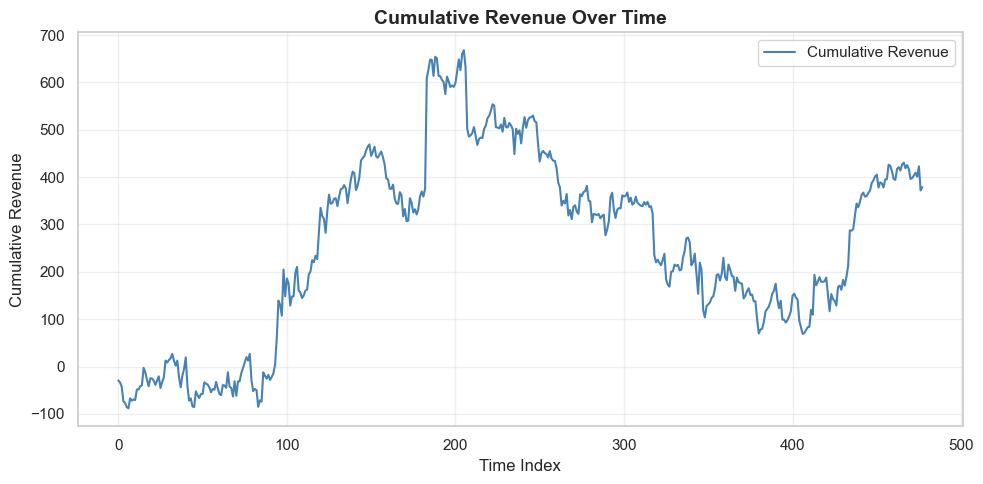

In [1493]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 假设 revenue_series 是 pandas Series 或 numpy array
# 示例：
# revenue_series = pd.Series([10, -5, 15, -3, 20])

# 1️⃣ 累积收益
cumulative_revenue = np.cumsum(revenue_series)

# 2️⃣ 绘图
plt.figure(figsize=(10, 5))
plt.plot(cumulative_revenue, label='Cumulative Revenue', color='steelblue', linewidth=1.5)
plt.title("Cumulative Revenue Over Time", fontsize=14, fontweight='bold')
plt.xlabel("Time Index")
plt.ylabel("Cumulative Revenue")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


In [1494]:
num

75

Text(0, 0.5, 'Density')

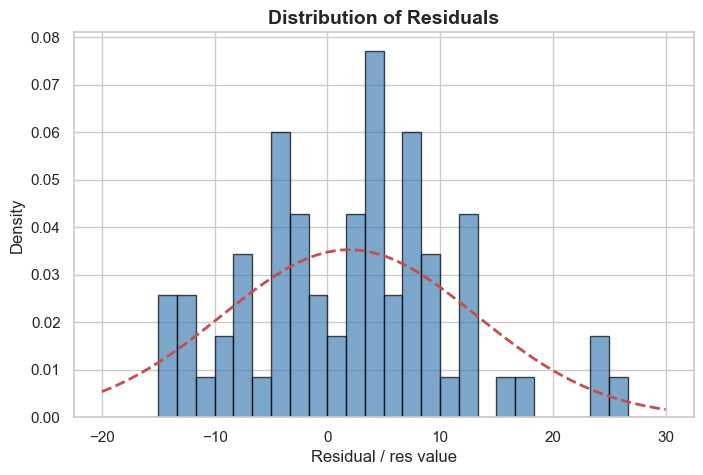

In [1495]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm

# 假设 res 是普通 list

# 1️⃣ 指定 x 轴范围
x_min, x_max = -20, 30  # 例如固定在 [-0.05, 0.05]

# 2️⃣ 绘制直方图
plt.figure(figsize=(8,5))
plt.hist(res_array, bins=30, range=(x_min, x_max), color='steelblue', edgecolor='black', alpha=0.7, density=True)

# 3️⃣ 拟合正态分布并绘制曲线（在同一 x 轴范围内）
mu, std = norm.fit(res_array)
x = np.linspace(x_min, x_max, 100)
plt.plot(x, norm.pdf(x, mu, std), 'r--', linewidth=2, label=f'Normal fit μ={mu:.4f}, σ={std:.4f}')

# 4️⃣ 图形美化
plt.title("Distribution of Residuals", fontsize=14, fontweight='bold')
plt.xlabel("Residual / res value")
plt.ylabel("Density")


In [1496]:

raw_text = """Sharpe Ratio: 0.03149628519143763 A: 0 B: 15 FW: 12 BW: 96 Num Trades: 799 Avg Revenue: 0.24864531787463598
Sharpe Ratio: 0.024334221758996938 A: 0 B: 15 FW: 12 BW: 192 Num Trades: 542 Avg Revenue: 0.18632069202593365
Sharpe Ratio: -0.014368588090950948 A: 0 B: 15 FW: 12 BW: 288 Num Trades: 423 Avg Revenue: -0.11473471197270618
Sharpe Ratio: 0.08258605675075921 A: 0 B: 15 FW: 12 BW: 576 Num Trades: 184 Avg Revenue: 0.5036146035968568
Sharpe Ratio: 0.05180629630322778 A: 0 B: 15 FW: 24 BW: 96 Num Trades: 401 Avg Revenue: 0.5351064311833423
Sharpe Ratio: -0.0063617752613703395 A: 0 B: 15 FW: 24 BW: 192 Num Trades: 264 Avg Revenue: -0.06294653982100702
Sharpe Ratio: 0.03887458098305434 A: 0 B: 15 FW: 24 BW: 288 Num Trades: 210 Avg Revenue: 0.32197831902858814
Sharpe Ratio: 0.09231317331541729 A: 0 B: 15 FW: 24 BW: 576 Num Trades: 91 Avg Revenue: 0.7239160032874842
Sharpe Ratio: -0.10851559839617217 A: 0 B: 15 FW: 48 BW: 96 Num Trades: 209 Avg Revenue: -1.462216654967771
Sharpe Ratio: -0.04324412255322344 A: 0 B: 15 FW: 48 BW: 192 Num Trades: 134 Avg Revenue: -0.7273743812934854
Sharpe Ratio: 0.14277593422954482 A: 0 B: 15 FW: 48 BW: 288 Num Trades: 100 Avg Revenue: 1.5153196636098432
Sharpe Ratio: -0.059341763589479096 A: 0 B: 15 FW: 48 BW: 576 Num Trades: 45 Avg Revenue: -0.5801110891047772
Sharpe Ratio: 0.016439782122569153 A: 0 B: 15 FW: 96 BW: 96 Num Trades: 115 Avg Revenue: 0.30544465775699325
Sharpe Ratio: 0.05354196239618247 A: 0 B: 15 FW: 96 BW: 192 Num Trades: 68 Avg Revenue: 1.0010792742267975
Sharpe Ratio: 0.04113143734388429 A: 0 B: 15 FW: 96 BW: 288 Num Trades: 50 Avg Revenue: 0.48743590874544823
Sharpe Ratio: -0.11084922038093574 A: 0 B: 15 FW: 96 BW: 576 Num Trades: 26 Avg Revenue: -1.9190109148331866
Sharpe Ratio: 0.028058714234236927 A: 0 B: 30 FW: 12 BW: 96 Num Trades: 938 Avg Revenue: 0.23331109538163036
Sharpe Ratio: 0.006819216441460355 A: 0 B: 30 FW: 12 BW: 192 Num Trades: 819 Avg Revenue: 0.05669079270503817
Sharpe Ratio: -0.000783040650550893 A: 0 B: 30 FW: 12 BW: 288 Num Trades: 766 Avg Revenue: -0.00671482058832693
Sharpe Ratio: -0.014765971603634692 A: 0 B: 30 FW: 12 BW: 576 Num Trades: 582 Avg Revenue: -0.11353444263673615
Sharpe Ratio: 0.05131985270089376 A: 0 B: 30 FW: 24 BW: 96 Num Trades: 473 Avg Revenue: 0.5616146971458849
Sharpe Ratio: -0.018600123710133018 A: 0 B: 30 FW: 24 BW: 192 Num Trades: 406 Avg Revenue: -0.2079570206926358
Sharpe Ratio: 0.008902093002514063 A: 0 B: 30 FW: 24 BW: 288 Num Trades: 385 Avg Revenue: 0.09367725445646466
Sharpe Ratio: -0.013528666695217843 A: 0 B: 30 FW: 24 BW: 576 Num Trades: 297 Avg Revenue: -0.14464219940580164
Sharpe Ratio: -0.0637928846971438 A: 0 B: 30 FW: 48 BW: 96 Num Trades: 244 Avg Revenue: -0.9364685915796539
Sharpe Ratio: -0.0955172071917547 A: 0 B: 30 FW: 48 BW: 192 Num Trades: 202 Avg Revenue: -1.6344835835970113
Sharpe Ratio: 0.08828457578433586 A: 0 B: 30 FW: 48 BW: 288 Num Trades: 191 Avg Revenue: 1.2414061769586417
Sharpe Ratio: -0.06062581051850848 A: 0 B: 30 FW: 48 BW: 576 Num Trades: 149 Avg Revenue: -0.831401198219036
Sharpe Ratio: 0.06851249744083936 A: 0 B: 30 FW: 96 BW: 96 Num Trades: 134 Avg Revenue: 1.4116028393424827
Sharpe Ratio: -0.031434050770218186 A: 0 B: 30 FW: 96 BW: 192 Num Trades: 99 Avg Revenue: -0.6424798140568375
Sharpe Ratio: 0.016639086706470747 A: 0 B: 30 FW: 96 BW: 288 Num Trades: 96 Avg Revenue: 0.30351515019954123
Sharpe Ratio: -0.10180935753150717 A: 0 B: 30 FW: 96 BW: 576 Num Trades: 74 Avg Revenue: -1.7519482639920887
Sharpe Ratio: 0.021997805206150037 A: 0 B: 45 FW: 12 BW: 96 Num Trades: 960 Avg Revenue: 0.19258897988732152
Sharpe Ratio: -0.006067017650922088 A: 0 B: 45 FW: 12 BW: 192 Num Trades: 866 Avg Revenue: -0.05194845176129227
Sharpe Ratio: 0.010756805501519681 A: 0 B: 45 FW: 12 BW: 288 Num Trades: 844 Avg Revenue: 0.09565225662050202
Sharpe Ratio: -0.003970175119155721 A: 0 B: 45 FW: 12 BW: 576 Num Trades: 731 Avg Revenue: -0.03345663837275874
Sharpe Ratio: 0.039293863545013234 A: 0 B: 45 FW: 24 BW: 96 Num Trades: 486 Avg Revenue: 0.4718102099189472
Sharpe Ratio: -0.01538817234384454 A: 0 B: 45 FW: 24 BW: 192 Num Trades: 428 Avg Revenue: -0.17832609244311212
Sharpe Ratio: 0.024662342243501494 A: 0 B: 45 FW: 24 BW: 288 Num Trades: 424 Avg Revenue: 0.2768977130351813
Sharpe Ratio: -0.005483362527215784 A: 0 B: 45 FW: 24 BW: 576 Num Trades: 368 Avg Revenue: -0.06087274609656048
Sharpe Ratio: -0.06433967014926938 A: 0 B: 45 FW: 48 BW: 96 Num Trades: 250 Avg Revenue: -1.021234006649676
Sharpe Ratio: -0.11431291558866093 A: 0 B: 45 FW: 48 BW: 192 Num Trades: 210 Avg Revenue: -2.0235072192639243
Sharpe Ratio: 0.07415799893533413 A: 0 B: 45 FW: 48 BW: 288 Num Trades: 211 Avg Revenue: 1.1339950020698972
Sharpe Ratio: -0.021908407489120978 A: 0 B: 45 FW: 48 BW: 576 Num Trades: 184 Avg Revenue: -0.32408350560143767
Sharpe Ratio: 0.07037933182035443 A: 0 B: 45 FW: 96 BW: 96 Num Trades: 137 Avg Revenue: 1.4451287302439924
Sharpe Ratio: -0.03231184927589842 A: 0 B: 45 FW: 96 BW: 192 Num Trades: 103 Avg Revenue: -0.6559046710964359
Sharpe Ratio: 0.02230415157790288 A: 0 B: 45 FW: 96 BW: 288 Num Trades: 106 Avg Revenue: 0.4369842934843726
Sharpe Ratio: -0.0817194546687775 A: 0 B: 45 FW: 96 BW: 576 Num Trades: 91 Avg Revenue: -1.3971647675096972
Sharpe Ratio: 0.010269299496886663 A: 0 B: 999 FW: 12 BW: 96 Num Trades: 963 Avg Revenue: 0.09215667019318181
Sharpe Ratio: -0.00666369068254007 A: 0 B: 999 FW: 12 BW: 192 Num Trades: 879 Avg Revenue: -0.06095802694520251
Sharpe Ratio: 0.015406475548207585 A: 0 B: 999 FW: 12 BW: 288 Num Trades: 867 Avg Revenue: 0.14127518928142427
Sharpe Ratio: 0.03499157778709623 A: 0 B: 999 FW: 12 BW: 576 Num Trades: 812 Avg Revenue: 0.3147788297677202
Sharpe Ratio: 0.029463719328422136 A: 0 B: 999 FW: 24 BW: 96 Num Trades: 487 Avg Revenue: 0.36070685610439385
Sharpe Ratio: -0.014172304739639745 A: 0 B: 999 FW: 24 BW: 192 Num Trades: 435 Avg Revenue: -0.16555449634586514
Sharpe Ratio: 0.03849466020096167 A: 0 B: 999 FW: 24 BW: 288 Num Trades: 436 Avg Revenue: 0.445575449273428
Sharpe Ratio: 0.058608375538489306 A: 0 B: 999 FW: 24 BW: 576 Num Trades: 406 Avg Revenue: 0.7045315019285054
Sharpe Ratio: -0.06433967014926938 A: 0 B: 999 FW: 48 BW: 96 Num Trades: 250 Avg Revenue: -1.021234006649676
Sharpe Ratio: -0.0908437878336045 A: 0 B: 999 FW: 48 BW: 192 Num Trades: 215 Avg Revenue: -1.6642426852172474
Sharpe Ratio: 0.08907624514870185 A: 0 B: 999 FW: 48 BW: 288 Num Trades: 216 Avg Revenue: 1.4101992364830893
Sharpe Ratio: 0.05491835002056793 A: 0 B: 999 FW: 48 BW: 576 Num Trades: 203 Avg Revenue: 0.916717382550018
Sharpe Ratio: 0.07037933182035443 A: 0 B: 999 FW: 96 BW: 96 Num Trades: 137 Avg Revenue: 1.4451287302439924
Sharpe Ratio: -0.02056452756803409 A: 0 B: 999 FW: 96 BW: 192 Num Trades: 105 Avg Revenue: -0.41507729303152224
Sharpe Ratio: 0.013126937569897511 A: 0 B: 999 FW: 96 BW: 288 Num Trades: 108 Avg Revenue: 0.2554170227235922
Sharpe Ratio: 0.011809442559373039 A: 0 B: 999 FW: 96 BW: 576 Num Trades: 100 Avg Revenue: 0.22562606546635358
Sharpe Ratio: 0.055848927996331094 A: 15 B: 15 FW: 12 BW: 96 Num Trades: 290 Avg Revenue: 0.5298641248562845
Sharpe Ratio: 0.013318826890905156 A: 15 B: 15 FW: 12 BW: 192 Num Trades: 338 Avg Revenue: 0.11517884593358857
Sharpe Ratio: -0.04243907249368543 A: 15 B: 15 FW: 12 BW: 288 Num Trades: 306 Avg Revenue: -0.3690672635923383
Sharpe Ratio: 0.0627080536237457 A: 15 B: 15 FW: 12 BW: 576 Num Trades: 165 Avg Revenue: 0.39883259816585476
Sharpe Ratio: 0.03489642512173953 A: 15 B: 15 FW: 24 BW: 96 Num Trades: 142 Avg Revenue: 0.45966014527116167
Sharpe Ratio: 0.014919759342858453 A: 15 B: 15 FW: 24 BW: 192 Num Trades: 165 Avg Revenue: 0.16658104286991238
Sharpe Ratio: 0.03131402208258884 A: 15 B: 15 FW: 24 BW: 288 Num Trades: 152 Avg Revenue: 0.2840463471501641
Sharpe Ratio: 0.051439839354517666 A: 15 B: 15 FW: 24 BW: 576 Num Trades: 81 Avg Revenue: 0.422655593946796
Sharpe Ratio: -0.20243709400117846 A: 15 B: 15 FW: 48 BW: 96 Num Trades: 73 Avg Revenue: -3.343781923392816
Sharpe Ratio: -0.041415797227852644 A: 15 B: 15 FW: 48 BW: 192 Num Trades: 86 Avg Revenue: -0.7930175353198353
Sharpe Ratio: 0.17088475758627233 A: 15 B: 15 FW: 48 BW: 288 Num Trades: 75 Avg Revenue: 1.934109401443034
Sharpe Ratio: -0.06968264616415895 A: 15 B: 15 FW: 48 BW: 576 Num Trades: 40 Avg Revenue: -0.7030466694530612
Sharpe Ratio: -0.12268135023066892 A: 15 B: 15 FW: 96 BW: 96 Num Trades: 45 Avg Revenue: -2.449609657320094
Sharpe Ratio: 0.09068608146919047 A: 15 B: 15 FW: 96 BW: 192 Num Trades: 45 Avg Revenue: 1.6814597728273424
Sharpe Ratio: 0.1956954184176273 A: 15 B: 15 FW: 96 BW: 288 Num Trades: 34 Avg Revenue: 2.2904067357006457
Sharpe Ratio: -0.12314221103316904 A: 15 B: 15 FW: 96 BW: 576 Num Trades: 23 Avg Revenue: -2.240857022122836
Sharpe Ratio: 0.04314385036710413 A: 15 B: 30 FW: 12 BW: 96 Num Trades: 427 Avg Revenue: 0.4234970527329707
Sharpe Ratio: -0.0025156477862193923 A: 15 B: 30 FW: 12 BW: 192 Num Trades: 614 Avg Revenue: -0.022721820726965724
Sharpe Ratio: -0.011810561837455904 A: 15 B: 30 FW: 12 BW: 288 Num Trades: 648 Avg Revenue: -0.10633525352691721
Sharpe Ratio: -0.02117569348638912 A: 15 B: 30 FW: 12 BW: 576 Num Trades: 563 Avg Revenue: -0.16507061097519726
Sharpe Ratio: 0.043697162671033726 A: 15 B: 30 FW: 24 BW: 96 Num Trades: 213 Avg Revenue: 0.5868517692813779
Sharpe Ratio: -0.010791179998817436 A: 15 B: 30 FW: 24 BW: 192 Num Trades: 307 Avg Revenue: -0.1313576280616571
Sharpe Ratio: 0.0031855886479314455 A: 15 B: 30 FW: 24 BW: 288 Num Trades: 327 Avg Revenue: 0.03555150072342624
Sharpe Ratio: -0.023960532840926994 A: 15 B: 30 FW: 24 BW: 576 Num Trades: 287 Avg Revenue: -0.2599302662473648
Sharpe Ratio: -0.08700616347656923 A: 15 B: 30 FW: 48 BW: 96 Num Trades: 107 Avg Revenue: -1.5706364357761409
Sharpe Ratio: -0.10561783071248676 A: 15 B: 30 FW: 48 BW: 192 Num Trades: 154 Avg Revenue: -1.9538767846154226
Sharpe Ratio: 0.09417068596818022 A: 15 B: 30 FW: 48 BW: 288 Num Trades: 166 Avg Revenue: 1.3893663767852036
Sharpe Ratio: -0.06293352453687401 A: 15 B: 30 FW: 48 BW: 576 Num Trades: 144 Avg Revenue: -0.8742753215489157
Sharpe Ratio: 0.030224672860313013 A: 15 B: 30 FW: 96 BW: 96 Num Trades: 63 Avg Revenue: 0.7186694167075328
Sharpe Ratio: -0.03530782279203489 A: 15 B: 30 FW: 96 BW: 192 Num Trades: 76 Avg Revenue: -0.7370158218660364
Sharpe Ratio: 0.05364100833302712 A: 15 B: 30 FW: 96 BW: 288 Num Trades: 80 Avg Revenue: 1.0329935999463196
Sharpe Ratio: -0.10567243139462809 A: 15 B: 30 FW: 96 BW: 576 Num Trades: 71 Avg Revenue: -1.8491492853320692
Sharpe Ratio: 0.031033982472028904 A: 15 B: 45 FW: 12 BW: 96 Num Trades: 449 Avg Revenue: 0.32711103505754524
Sharpe Ratio: -0.01717188475356537 A: 15 B: 45 FW: 12 BW: 192 Num Trades: 661 Avg Revenue: -0.15940743778678082
Sharpe Ratio: 0.002510053751285272 A: 15 B: 45 FW: 12 BW: 288 Num Trades: 726 Avg Revenue: 0.023373020486115465
Sharpe Ratio: -0.008456091328624933 A: 15 B: 45 FW: 12 BW: 576 Num Trades: 712 Avg Revenue: -0.0720709424367167
Sharpe Ratio: 0.025901703431229463 A: 15 B: 45 FW: 24 BW: 96 Num Trades: 226 Avg Revenue: 0.3922806952545939
Sharpe Ratio: -0.007773710803633718 A: 15 B: 45 FW: 24 BW: 192 Num Trades: 329 Avg Revenue: -0.09793255008927222
Sharpe Ratio: 0.021402583394484438 A: 15 B: 45 FW: 24 BW: 288 Num Trades: 366 Avg Revenue: 0.2540006232178644
Sharpe Ratio: -0.013436877030946 A: 15 B: 45 FW: 24 BW: 576 Num Trades: 358 Avg Revenue: -0.15095649093018126
Sharpe Ratio: -0.08618073886970015 A: 15 B: 45 FW: 48 BW: 96 Num Trades: 113 Avg Revenue: -1.72449791101797
Sharpe Ratio: -0.12765953032733432 A: 15 B: 45 FW: 48 BW: 192 Num Trades: 162 Avg Revenue: -2.442394178948166
Sharpe Ratio: 0.07814580886970111 A: 15 B: 45 FW: 48 BW: 288 Num Trades: 186 Avg Revenue: 1.2516085171182338
Sharpe Ratio: -0.02302827314112004 A: 15 B: 45 FW: 48 BW: 576 Num Trades: 179 Avg Revenue: -0.3444035351903464
Sharpe Ratio: 0.03485682809496444 A: 15 B: 45 FW: 96 BW: 96 Num Trades: 66 Avg Revenue: 0.8197580124864982
Sharpe Ratio: -0.036253544515938284 A: 15 B: 45 FW: 96 BW: 192 Num Trades: 80 Avg Revenue: -0.74957352491406
Sharpe Ratio: 0.05369627993083573 A: 15 B: 45 FW: 96 BW: 288 Num Trades: 90 Avg Revenue: 1.1091374298432557
Sharpe Ratio: -0.08444179859248052 A: 15 B: 45 FW: 96 BW: 576 Num Trades: 88 Avg Revenue: -1.4634934268925546
Sharpe Ratio: 0.010281631604879448 A: 15 B: 999 FW: 12 BW: 96 Num Trades: 452 Avg Revenue: 0.11224404302000705
Sharpe Ratio: -0.016955630935962467 A: 15 B: 999 FW: 12 BW: 192 Num Trades: 674 Avg Revenue: -0.1690846629623384
Sharpe Ratio: 0.00816142694592798 A: 15 B: 999 FW: 12 BW: 288 Num Trades: 749 Avg Revenue: 0.07840306727932037
Sharpe Ratio: 0.03172966651543136 A: 15 B: 999 FW: 12 BW: 576 Num Trades: 793 Avg Revenue: 0.28845233468717935
Sharpe Ratio: 0.00993423732719765 A: 15 B: 999 FW: 24 BW: 96 Num Trades: 227 Avg Revenue: 0.15427274902982244
Sharpe Ratio: -0.006547069005989342 A: 15 B: 999 FW: 24 BW: 192 Num Trades: 336 Avg Revenue: -0.08307275989336281
Sharpe Ratio: 0.036743454056207284 A: 15 B: 999 FW: 24 BW: 288 Num Trades: 378 Avg Revenue: 0.4492870202487727
Sharpe Ratio: 0.05283462673304393 A: 15 B: 999 FW: 24 BW: 576 Num Trades: 396 Avg Revenue: 0.6424205469532895
Sharpe Ratio: -0.08618073886970015 A: 15 B: 999 FW: 48 BW: 96 Num Trades: 113 Avg Revenue: -1.72449791101797
Sharpe Ratio: -0.09917938260436235 A: 15 B: 999 FW: 48 BW: 192 Num Trades: 167 Avg Revenue: -1.967326456681958
Sharpe Ratio: 0.09415167528173649 A: 15 B: 999 FW: 48 BW: 288 Num Trades: 191 Avg Revenue: 1.5608862504062335
Sharpe Ratio: 0.055114318782317 A: 15 B: 999 FW: 48 BW: 576 Num Trades: 198 Avg Revenue: 0.9296806105517482
Sharpe Ratio: 0.03485682809496444 A: 15 B: 999 FW: 96 BW: 96 Num Trades: 66 Avg Revenue: 0.8197580124864982
Sharpe Ratio: -0.021386549419185878 A: 15 B: 999 FW: 96 BW: 192 Num Trades: 82 Avg Revenue: -0.4389123980305082
Sharpe Ratio: 0.04301502788316084 A: 15 B: 999 FW: 96 BW: 288 Num Trades: 92 Avg Revenue: 0.8813812177249724
Sharpe Ratio: 0.011140003728528407 A: 15 B: 999 FW: 96 BW: 576 Num Trades: 97 Avg Revenue: 0.21564101879869074
Sharpe Ratio: 0.19483543564381559 A: 25 B: 15 FW: 12 BW: 96 Num Trades: 35 Avg Revenue: 2.67618615300561
Sharpe Ratio: 0.04973425637808859 A: 25 B: 15 FW: 12 BW: 192 Num Trades: 68 Avg Revenue: 0.4849582059604753
Sharpe Ratio: -0.13963383872881516 A: 25 B: 15 FW: 12 BW: 288 Num Trades: 76 Avg Revenue: -1.8062752973640326
Sharpe Ratio: 0.25456532439861923 A: 25 B: 15 FW: 12 BW: 576 Num Trades: 19 Avg Revenue: 1.7708831379767214
Sharpe Ratio: 0.06753445496125933 A: 25 B: 15 FW: 24 BW: 96 Num Trades: 22 Avg Revenue: 1.7179027579305943
Sharpe Ratio: -0.017961936646185457 A: 25 B: 15 FW: 24 BW: 192 Num Trades: 33 Avg Revenue: -0.2567730709004229
Sharpe Ratio: -0.11503458477485118 A: 25 B: 15 FW: 24 BW: 288 Num Trades: 39 Avg Revenue: -1.4090247713565769
Sharpe Ratio: 0.29802364133511905 A: 25 B: 15 FW: 24 BW: 576 Num Trades: 11 Avg Revenue: 2.5269975050139264
Sharpe Ratio: -0.5989546918279915 A: 25 B: 15 FW: 48 BW: 96 Num Trades: 13 Avg Revenue: -12.149295463615003
Sharpe Ratio: -0.2417568190063171 A: 25 B: 15 FW: 48 BW: 192 Num Trades: 16 Avg Revenue: -5.66237650514733
Sharpe Ratio: 0.07420710270937941 A: 25 B: 15 FW: 48 BW: 288 Num Trades: 17 Avg Revenue: 1.0905748041895318
Sharpe Ratio: -0.21857274396878293 A: 25 B: 15 FW: 48 BW: 576 Num Trades: 5 Avg Revenue: -1.574137073410397
Sharpe Ratio: 0.3390429786231586 A: 25 B: 15 FW: 96 BW: 96 Num Trades: 11 Avg Revenue: 7.789469941912199
Sharpe Ratio: -0.48461064190247316 A: 25 B: 15 FW: 96 BW: 192 Num Trades: 8 Avg Revenue: -6.9113356141143525
Sharpe Ratio: -0.19563824771689092 A: 25 B: 15 FW: 96 BW: 288 Num Trades: 5 Avg Revenue: -2.976439796985324
Sharpe Ratio: 1.0029659747537052 A: 25 B: 15 FW: 96 BW: 576 Num Trades: 3 Avg Revenue: 5.156062963776897
Sharpe Ratio: 0.032321514409336845 A: 25 B: 30 FW: 12 BW: 96 Num Trades: 123 Avg Revenue: 0.38990552620289476
Sharpe Ratio: -0.00660479524724084 A: 25 B: 30 FW: 12 BW: 192 Num Trades: 275 Avg Revenue: -0.06709202495058036
Sharpe Ratio: -0.06477536850302912 A: 25 B: 30 FW: 12 BW: 288 Num Trades: 360 Avg Revenue: -0.6770809693603708
Sharpe Ratio: -0.026641805368493605 A: 25 B: 30 FW: 12 BW: 576 Num Trades: 375 Avg Revenue: -0.22806071127987718
Sharpe Ratio: 0.09259012566491207 A: 25 B: 30 FW: 24 BW: 96 Num Trades: 74 Avg Revenue: 1.7120816914692427
Sharpe Ratio: -0.032245600197218956 A: 25 B: 30 FW: 24 BW: 192 Num Trades: 140 Avg Revenue: -0.4697238136110885
Sharpe Ratio: -0.0757814980795831 A: 25 B: 30 FW: 24 BW: 288 Num Trades: 183 Avg Revenue: -0.9603241629729845
Sharpe Ratio: -0.03072432593269184 A: 25 B: 30 FW: 24 BW: 576 Num Trades: 195 Avg Revenue: -0.3684137109063652
Sharpe Ratio: -0.13776021018610715 A: 25 B: 30 FW: 48 BW: 96 Num Trades: 38 Avg Revenue: -3.2136849964987775
Sharpe Ratio: -0.15885078204773623 A: 25 B: 30 FW: 48 BW: 192 Num Trades: 67 Avg Revenue: -3.140269622594805
Sharpe Ratio: 0.09879415289462373 A: 25 B: 30 FW: 48 BW: 288 Num Trades: 91 Avg Revenue: 1.6644117365945272
Sharpe Ratio: -0.06009068535015338 A: 25 B: 30 FW: 48 BW: 576 Num Trades: 99 Avg Revenue: -0.9229074841808187
Sharpe Ratio: 0.3372597601056358 A: 25 B: 30 FW: 96 BW: 96 Num Trades: 25 Avg Revenue: 9.72695979594022
Sharpe Ratio: -0.20836979404865222 A: 25 B: 30 FW: 96 BW: 192 Num Trades: 33 Avg Revenue: -4.604649836176855
Sharpe Ratio: -0.021757249271681836 A: 25 B: 30 FW: 96 BW: 288 Num Trades: 46 Avg Revenue: -0.5172553972620669
Sharpe Ratio: -0.027532876025382468 A: 25 B: 30 FW: 96 BW: 576 Num Trades: 46 Avg Revenue: -0.4789101641922489
Sharpe Ratio: 0.012396151307548902 A: 25 B: 45 FW: 12 BW: 96 Num Trades: 143 Avg Revenue: 0.16890057142402848
Sharpe Ratio: -0.03262109898155723 A: 25 B: 45 FW: 12 BW: 192 Num Trades: 322 Avg Revenue: -0.34120318419911433
Sharpe Ratio: -0.03549113988903062 A: 25 B: 45 FW: 12 BW: 288 Num Trades: 437 Avg Revenue: -0.3788464452647567
Sharpe Ratio: -0.009041806974086951 A: 25 B: 45 FW: 12 BW: 576 Num Trades: 524 Avg Revenue: -0.08378344230126
Sharpe Ratio: 0.03856944133487871 A: 25 B: 45 FW: 24 BW: 96 Num Trades: 86 Avg Revenue: 0.8153632796157296
Sharpe Ratio: -0.02372886512116304 A: 25 B: 45 FW: 24 BW: 192 Num Trades: 162 Avg Revenue: -0.35589105598761844
Sharpe Ratio: -0.034865251709438716 A: 25 B: 45 FW: 24 BW: 288 Num Trades: 221 Avg Revenue: -0.47057925947707385
Sharpe Ratio: -0.015830667260851715 A: 25 B: 45 FW: 24 BW: 576 Num Trades: 266 Avg Revenue: -0.19279365025094866
Sharpe Ratio: -0.17991447617620737 A: 25 B: 45 FW: 48 BW: 96 Num Trades: 43 Avg Revenue: -4.606786466948585
Sharpe Ratio: -0.1952380024452399 A: 25 B: 45 FW: 48 BW: 192 Num Trades: 75 Avg Revenue: -4.068918624969062
Sharpe Ratio: 0.0725900584440937 A: 25 B: 45 FW: 48 BW: 288 Num Trades: 110 Avg Revenue: 1.3383735701217947
Sharpe Ratio: -0.012418872101456946 A: 25 B: 45 FW: 48 BW: 576 Num Trades: 134 Avg Revenue: -0.2023912494770838
Sharpe Ratio: 0.30835083997180984 A: 25 B: 45 FW: 96 BW: 96 Num Trades: 27 Avg Revenue: 8.750232048526794
Sharpe Ratio: -0.19517243523179098 A: 25 B: 45 FW: 96 BW: 192 Num Trades: 37 Avg Revenue: -4.213679030409249
Sharpe Ratio: -0.0009264948037598663 A: 25 B: 45 FW: 96 BW: 288 Num Trades: 55 Avg Revenue: -0.0232848944415025
Sharpe Ratio: -0.018058934887964662 A: 25 B: 45 FW: 96 BW: 576 Num Trades: 63 Avg Revenue: -0.3099633311239893
Sharpe Ratio: -0.0341359823576896 A: 25 B: 999 FW: 12 BW: 96 Num Trades: 146 Avg Revenue: -0.4930531889188935
Sharpe Ratio: -0.030412880249588076 A: 25 B: 999 FW: 12 BW: 192 Num Trades: 335 Avg Revenue: -0.3536184231990112
Sharpe Ratio: -0.02439265037554743 A: 25 B: 999 FW: 12 BW: 288 Num Trades: 460 Avg Revenue: -0.2691322001334948
Sharpe Ratio: 0.03959972094406681 A: 25 B: 999 FW: 12 BW: 576 Num Trades: 605 Avg Revenue: 0.39033832835705007
Sharpe Ratio: 0.008690272800034857 A: 25 B: 999 FW: 24 BW: 96 Num Trades: 87 Avg Revenue: 0.18949102240441676
Sharpe Ratio: -0.02096159710204391 A: 25 B: 999 FW: 24 BW: 192 Num Trades: 169 Avg Revenue: -0.31566265925913356
Sharpe Ratio: -0.008348782806817199 A: 25 B: 999 FW: 24 BW: 288 Num Trades: 233 Avg Revenue: -0.11644528235251321
Sharpe Ratio: 0.06421057565354367 A: 25 B: 999 FW: 24 BW: 576 Num Trades: 304 Avg Revenue: 0.8459139782228785
Sharpe Ratio: -0.17991447617620737 A: 25 B: 999 FW: 48 BW: 96 Num Trades: 43 Avg Revenue: -4.606786466948585
Sharpe Ratio: -0.13442182118412788 A: 25 B: 999 FW: 48 BW: 192 Num Trades: 80 Avg Revenue: -2.9755569768620473
Sharpe Ratio: 0.09653798412932921 A: 25 B: 999 FW: 48 BW: 288 Num Trades: 115 Avg Revenue: 1.8482711509304037
Sharpe Ratio: 0.07770104775558943 A: 25 B: 999 FW: 48 BW: 576 Num Trades: 153 Avg Revenue: 1.4287880147607115
Sharpe Ratio: 0.30835083997180984 A: 25 B: 999 FW: 96 BW: 96 Num Trades: 27 Avg Revenue: 8.750232048526794
Sharpe Ratio: -0.15849921958040294 A: 25 B: 999 FW: 96 BW: 192 Num Trades: 39 Avg Revenue: -3.3828476607825415
Sharpe Ratio: -0.014187468736392938 A: 25 B: 999 FW: 96 BW: 288 Num Trades: 57 Avg Revenue: -0.35115729560488007
Sharpe Ratio: 0.09158472471514259 A: 25 B: 999 FW: 96 BW: 576 Num Trades: 72 Avg Revenue: 1.8080126462389785
"""

In [1497]:
import re
import pandas as pd

# 用正则匹配每行的数据
pattern = re.compile(
    r"Sharpe Ratio:\s*([-0-9.]+)\s*A:\s*(\d+)\s*B:\s*(\d+)\s*FW:\s*(\d+)\s*BW:\s*(\d+)\s*Num Trades:\s*(\d+)\s*Avg Revenue:\s*([-0-9.]+)"
)

# 提取所有匹配结果
records = pattern.findall(raw_text)

# 转换为 DataFrame
cols = ["Sharpe", "A", "B", "FW", "BW", "NumTrades", "AvgRevenue"]
df = pd.DataFrame(records, columns=cols).astype(float)

print("共提取结果行数：", len(df))
df.head()


共提取结果行数： 192


,Sharpe,A,B,FW,BW,NumTrades,AvgRevenue
0,0.031496,0.0,15.0,12.0,96.0,799.0,0.248645
1,0.024334,0.0,15.0,12.0,192.0,542.0,0.186321
2,-0.014369,0.0,15.0,12.0,288.0,423.0,-0.114735
3,0.082586,0.0,15.0,12.0,576.0,184.0,0.503615
4,0.051806,0.0,15.0,24.0,96.0,401.0,0.535106


In [1498]:
# 按 Avg Revenue 从大到小排序
df_sorted = df.sort_values(by="AvgRevenue", ascending=False).reset_index(drop=True)

# 显示前20条
df_sorted.head(40)


,Sharpe,A,B,FW,BW,NumTrades,AvgRevenue
0,0.337260,25.0,30.0,96.0,96.0,25.0,9.726960
1,0.308351,25.0,999.0,96.0,96.0,27.0,8.750232
2,0.308351,25.0,45.0,96.0,96.0,27.0,8.750232
3,0.339043,25.0,15.0,96.0,96.0,11.0,7.789470
4,1.002966,25.0,15.0,96.0,576.0,3.0,5.156063
5,0.194835,25.0,15.0,12.0,96.0,35.0,2.676186
6,0.298024,25.0,15.0,24.0,576.0,11.0,2.526998
7,0.195695,15.0,15.0,96.0,288.0,34.0,2.290407
8,0.170885,15.0,15.0,48.0,288.0,75.0,1.934109
9,0.096538,25.0,999.0,48.0,288.0,115.0,1.848271
